In [1]:
# Upload your kaggle.json file
from google.colab import files
files.upload()  # Select and upload kaggle.json

# Install kaggle package
!pip install -q kaggle

# Move kaggle.json to the correct directory
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [2]:
# Replace with your dataset path (find it on the dataset's page)
!kaggle datasets download -d pkdarabi/cardetection

# Unzip the dataset
!unzip cardetection.zip -d /content/cardetection

Streaming output truncated to the last 5000 lines.
  inflating: /content/cardetection/car/train/labels/00000_00003_00024_png.rf.08957035e670072dbb22d8f9905e9b84.txt  
  inflating: /content/cardetection/car/train/labels/00000_00003_00025_png.rf.11e558fae394d310693ee9223b8962ca.txt  
  inflating: /content/cardetection/car/train/labels/00000_00003_00026_png.rf.1f6b33373353f896f2c2025ffd264e51.txt  
  inflating: /content/cardetection/car/train/labels/00000_00003_00026_png.rf.a3b6c2dcd4ee9a8064667b7bb266590b.txt  
  inflating: /content/cardetection/car/train/labels/00000_00003_00027_png.rf.c1381ed46ee0d7e21877ea3d7ef86127.txt  
  inflating: /content/cardetection/car/train/labels/00000_00003_00029_png.rf.8e24d2606537779612888c6a06c7043d.txt  
  inflating: /content/cardetection/car/train/labels/00000_00004_00000_png.rf.45dccdbf08ed12f25d7742d8bf88c102.txt  
  inflating: /content/cardetection/car/train/labels/00000_00004_00001_png.rf.557d3494b3e633e29069a6f42918334e.txt  
  inflating: /content

# Introduction

This project is a Traffic Sign Detection system which utilizes computer vision to recognize and interpret traffic signs on the road automatically. This technology is critical for enhancing driving safety, guiding traffic behavior and aiding in the decision-making processes of autonomous vehicles. Effective traffic sign detection not only helps drivers adhere to traffic regulations, but also reduces traffic accidents and improves traffic flow management.

Here I am going to use **YOLOv8** as the model. For those of you who do not know about YOLO, You Only Look Once (YOLO) is a series of real-time object detection systems based on convolutional neural networks. First introduced by Joseph Redmon et al. in 2015, YOLO has undergone several iterations and improvements, becoming one of the most popular object detection frameworks.


For data we are going to use [Traffic Signs Detection](https://www.kaggle.com/datasets/pkdarabi/cardetection) by [@pkdarabi](https://www.kaggle.com/pkdarabi)

This dataset is a traffic sign image dataset containing 4969 samples, which (as you can see in the image) is correctly divided into three parts: Train, Valid, and Test!!

![](https://www.googleapis.com/download/storage/v1/b/kaggle-user-content/o/inbox%2F14850461%2F69bf06b5bd76b597644880af6c884260%2Fssss.png?generation=1701092847791766&alt=media)

Now let's roll!

# Installing YOLOv8

In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 65.0 MB/s eta 0:00:00


# Import Essential Libraries

In [18]:
import os
import random
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO
from PIL import Image
from glob import glob

# Disable warnings to maintain clean output cells
import warnings
warnings.filterwarnings('ignore')

# Dataset Exploration

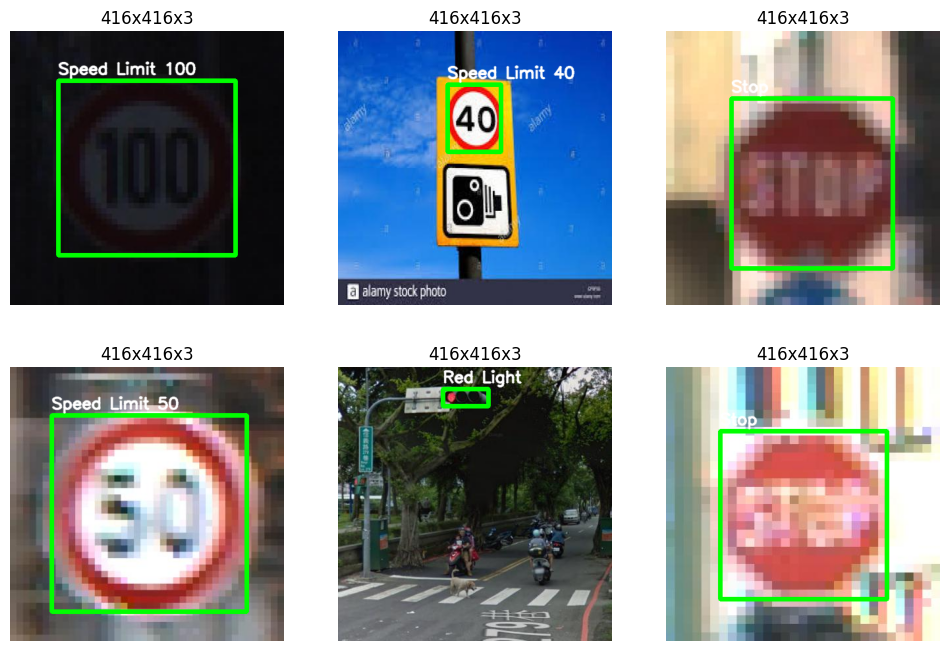

In [5]:
# Define the paths to images and labels directories
train_images = "/content/cardetection/car/train/images"
train_labels = "/content/cardetection/car/train/labels"

# Get a list of all images
image_files = os.listdir(train_images)

# Take out 6 images randomly
random_images = random.sample(image_files, 6)

# Set up the plot
# matplotlib.pyplot.subplots(nrows, ncols, figsize)
fig, axs = plt.subplots(2, 3, figsize=(12, 8))

# Load Class Names
class_names = {
    0: "Green Light",
    1: "Red Light",
    2: "Speed Limit 10",
    3: "Speed Limit 100",
    4: "Speed Limit 110",
    5: "Speed Limit 120",
    6: "Speed Limit 20",
    7: "Speed Limit 30",
    8: "Speed Limit 40",
    9: "Speed Limit 50",
    10: "Speed Limit 60",
    11: "Speed Limit 70",
    12: "Speed Limit 80",
    13: "Speed Limit 90",
    14: "Stop"
}

for i, image_file in enumerate(random_images):
    row = i // 3
    col = i % 3

    # Load the image file
    image = cv2.imread(os.path.join(train_images, image_file))

    # Load the labels for the image
    label_file = os.path.splitext(image_file)[0] + ".txt"
    label_path = os.path.join(train_labels, label_file)
    with open(label_path, "r") as f:
        labels = f.read().strip().split("\n")

    # Loop over the labels and plot the bounding boxes
    for label in labels:
        if len(label.split()) != 5:
            continue
        class_id, x_center, y_center, width, height = map(float, label.split())
        x_min = int((x_center - width/2) * image.shape[1])
        y_min = int((y_center - height/2) * image.shape[0])
        x_max = int((x_center + width/2) * image.shape[1])
        y_max = int((y_center + height/2) * image.shape[0])

        # Make a green rectangular bounding box around the detected object
        # Eg-> cv2.rectangle(image, Min point of BB, Max point of BB, RGB code of color, thickness)
        cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (0, 255, 0), 5)

        # Add class name to the bounding box
        class_name = class_names.get(int(class_id), "unknown")
        cv2.putText(image, class_name, (x_min, y_min - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)

    # Display the image with bounding boxes
    axs[row, col].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axs[row, col].axis('off')

    # Display the image with its dimensions
    h, w, c = image.shape
    axs[row, col].set_title(f"{h}x{w}x{c}")

plt.show()

# Model Training

In [7]:
model = YOLO('yolov8n.pt')

results = model.train(
    data='/content/cardetection/car/data.yaml',
    epochs=10,
    imgsz=416,
    patience=50,
    batch=32,
    optimizer='auto',
    lr0 = 0.0001,
    lrf=0.1,
    seed=0,
    dropout=0.2,
    plots=True
)

Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/cardetection/car/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.2, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspec

In [9]:
# Save the trained model
model.save('yolov8_trained.pt')
print("Model trained and saved successfully!")

Model trained and saved successfully!


# Model Performance

In [10]:
# Define the path to the directory
post_training_files_path = "/content/runs/detect/train"
# List the files in the directory
!ls {post_training_files_path}

args.yaml			 labels.jpg		val_batch0_pred.jpg
BoxF1_curve.png			 results.csv		val_batch1_labels.jpg
BoxP_curve.png			 results.png		val_batch1_pred.jpg
BoxPR_curve.png			 train_batch0.jpg	val_batch2_labels.jpg
BoxR_curve.png			 train_batch1.jpg	val_batch2_pred.jpg
confusion_matrix_normalized.png  train_batch2.jpg	weights
confusion_matrix.png		 val_batch0_labels.jpg


Display Images from Post-Training Directory



In [11]:
# Iterate through the images in the directory
for filename in os.listdir(post_training_files_path):
  if filename.lower().endswith(('.jpg', '.png')):
    image_path = os.path.join(post_training_files_path, filename)
    image = Image.open(image_path)

    # Display the image
    plt.figure(figsize=(12, 12), dpi=150)
    plt.imshow(image)
    plt.title(f"Image: {filename[:-4]}", fontsize=20, fontweight='bold')
    plt.axis('off')
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

# Model Evaluation

In [12]:
weights_path = "/content/runs/detect/train/weights"
!ls {weights_path}

best.pt  last.pt


Evaluating model performance on validation set

In [13]:
best_model_path = os.path.join(weights_path, "best.pt")
# Using the best model for evaluating the validation set
best_model = YOLO(best_model_path)
metrics = best_model.val(split='val')

Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 73 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 479.4±93.7 MB/s, size: 16.0 KB)
val: Scanning /content/cardetection/car/valid/labels.cache... 801 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 801/801 210.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 8.7it/s 5.9s
                   all        801        944      0.923      0.812      0.897      0.767
           Green Light         87        122      0.805       0.54      0.682       0.38
             Red Light         74        108      0.867      0.528      0.689      0.386
       Speed Limit 100         52         52      0.891      0.942       0.96      0.851
       Speed Limit 110         17         17      0.892      0.765      0.884      0.801
       Speed Limit 120         60         6

Visualizing the Validation set evaluation

In [14]:
val_path = '/content/runs/detect/val'

!ls {val_path}

BoxF1_curve.png  confusion_matrix_normalized.png  val_batch1_labels.jpg
BoxP_curve.png	 confusion_matrix.png		  val_batch1_pred.jpg
BoxPR_curve.png  val_batch0_labels.jpg		  val_batch2_labels.jpg
BoxR_curve.png	 val_batch0_pred.jpg		  val_batch2_pred.jpg


In [15]:
precision = round(metrics.results_dict["metrics/precision(B)"] * 100, 2)
recall = round(metrics.results_dict["metrics/recall(B)"] * 100, 2)
mAP50 = round(metrics.results_dict["metrics/mAP50(B)"] * 100, 2)
mAP50_95 = round(metrics.results_dict["metrics/mAP50-95(B)"] * 100, 2)

import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "mAP50", "mAP50_95"],
    "Value": [precision, recall, mAP50, mAP50_95]
})
metrics_df

,Metric,Value
0,Precision,92.32
1,Recall,81.17
2,mAP50,89.74
3,mAP50_95,76.72


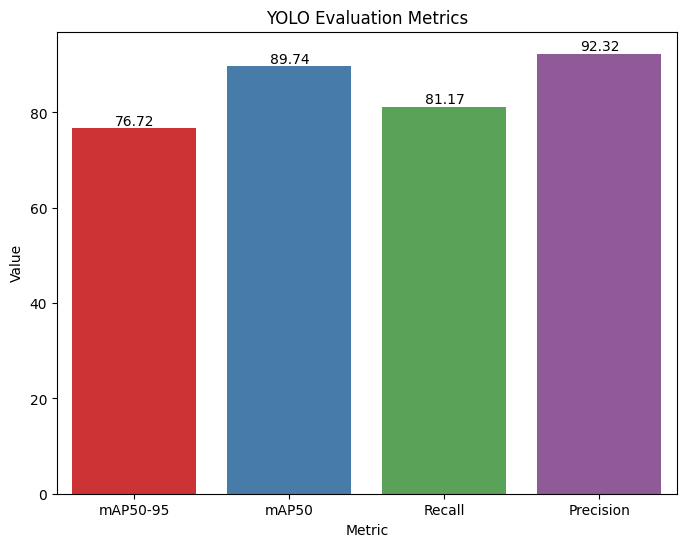

In [16]:
import seaborn as sns
%matplotlib inline
ax = sns.barplot(x=['mAP50-95', 'mAP50', 'Recall', 'Precision'], y=[mAP50_95, mAP50, recall, precision], palette='Set1')

# Setting the title and axis labels
ax.set_title('YOLO Evaluation Metrics')
ax.set_xlabel('Metric')
ax.set_ylabel('Value')

# Set the figure size
fig = plt.gcf()
fig.set_size_inches(8, 6)


for p in ax.patches:
  ax.annotate('{:.2f}'.format(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')

# Show the plot
plt.show()

# Model Inference

In [17]:
# Let's get the test images
test_images_path = "/content/cardetection/car/test/images"
image_files = [file for file in os.listdir(test_images_path) if file.lower().endswith((".jpg"))]

# Get prediction for first 15 images
for image_file in image_files[:15]:
  image_path = os.path.join(test_images_path, image_file)
  results = best_model.predict(image_path, imgsz=416, save=True, conf=0.6)


image 1/1 /content/cardetection/car/test/images/000488_jpg.rf.39fb3e780926eca95137e27b755f19af.jpg: 416x416 1 Speed Limit 70, 8.2ms
Speed: 1.1ms preprocess, 8.2ms inference, 2.3ms postprocess per image at shape (1, 3, 416, 416)
Results saved to /content/runs/detect/predict

image 1/1 /content/cardetection/car/test/images/000753_jpg.rf.23d05489386c3399c5d26ac779015d26.jpg: 416x416 (no detections), 6.0ms
Speed: 2.0ms preprocess, 6.0ms inference, 0.5ms postprocess per image at shape (1, 3, 416, 416)
Results saved to /content/runs/detect/predict

image 1/1 /content/cardetection/car/test/images/FisheyeCamera_1_00098_png.rf.937d582ee38fb9c9007c37c872df3176.jpg: 416x416 (no detections), 5.8ms
Speed: 1.6ms preprocess, 5.8ms inference, 0.5ms postprocess per image at shape (1, 3, 416, 416)
Results saved to /content/runs/detect/predict

image 1/1 /content/cardetection/car/test/images/FisheyeCamera_1_00587_png.rf.8f637c2480c931d014f8cc2877541abd.jpg: 416x416 (no detections), 5.9ms
Speed: 0.7ms pr

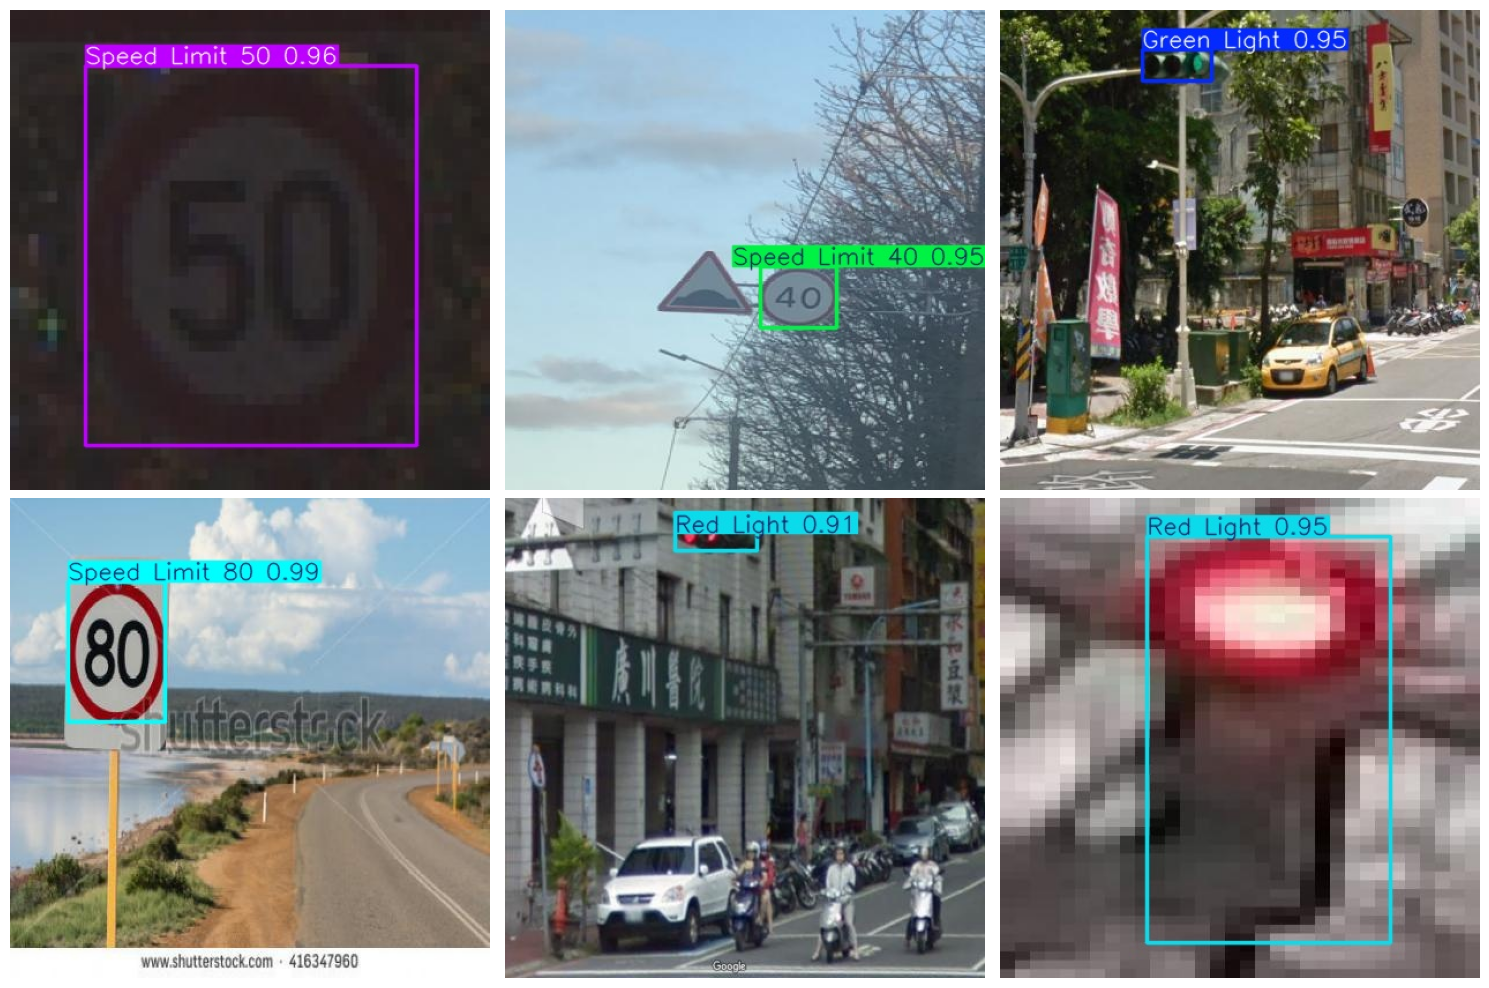

In [21]:
# Get the list of image paths
image_paths = glob('/content/runs/detect/predict/*.jpg')[6:12]  # Adjust to get up to 9 images

# Set up the plot with 2 rows and 3 columns
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# Loop through the image paths and display them
for i, image_path in enumerate(image_paths):
    row = i // 3
    col = i % 3
    image = Image.open(image_path)
    axs[row, col].imshow(image)
    axs[row, col].axis('off')

# Hide any unused subplots
for j in range(len(image_paths), 6):
    row = j // 3
    col = j % 3
    axs[row, col].axis('off')

plt.tight_layout()
plt.show()

Model Inference on an unseen video

In [23]:
video_path = "/content/cardetection/video.mp4"

best_model.predict(video_path, conf=0.6, save=True)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/508) /content/cardetection/video.mp4: 416x416 1 Stop, 9.5ms
video 1/1 (frame 2/508) /content/cardetection/video.mp4: 416x416 1 Stop, 6.0ms
video 1/1 (frame 3/508) /content/cardetection/video.mp4: 416x416 1 Stop, 5.9ms
video 1/1 (frame 4/508) /content/cardetection/video.mp4: 416x416 (no detections), 5.8ms
video 1/1 (frame 5/508) /content/cardetection/video.mp4: 416x416 1 Stop, 6.1ms
video 1/1 (frame 6/508) /content/cardetection/video.mp

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Green Light', 1: 'Red Light', 2: 'Speed Limit 10', 3: 'Speed Limit 100', 4: 'Speed Limit 110', 5: 'Speed Limit 120', 6: 'Speed Limit 20', 7: 'Speed Limit 30', 8: 'Speed Limit 40', 9: 'Speed Limit 50', 10: 'Speed Limit 60', 11: 'Speed Limit 70', 12: 'Speed Limit 80', 13: 'Speed Limit 90', 14: 'Stop'}
 obb: None
 orig_img: array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        ...,
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
     

In [24]:
from IPython.display import Video
!ffmpeg -y -loglevel panic -i /content/runs/detect/predict/video.avi result_out.mp4

#Display the converted MP4 video
Video("result_out.mp4",embed=True, width=960)

# Export the Model to ONNX format

In [25]:
# Export the model to ONNX (Open Neural Network Exchange) format
onnx_model = best_model.export(format="onnx")

Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 19, 3549) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 14 packages in 168ms
Prepared 6 packages in 8.87s
Installed 6 packages in 318ms
 + colorama==0.4.6
 + coloredlogs==15.0.1
 + humanfriendly==10.0
 + onnx==1.20.1
 + onnxruntime-gpu==1.23.2
 + onnxslim==0.1.82

requirements: AutoUpdate success ✅ 10.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 22...
ONNX: slimming with onnxslim 0.1.82...
ONNX: e

Thank You!

Code adapted from [@fhabibimoghaddam](https://www.kaggle.com/fhabibimoghaddam), “Real Time Traffic Sign Detection with YOLOv8”, available at [link](https://www.kaggle.com/code/fhabibimoghaddam/real-time-traffic-sign-detection-with-yolov8)